In [1]:
import sys
sys.path.append(".")

In [2]:
from config.spark_config import create_spark_session
from src.data_ingestion import load_data

In [3]:
spark = create_spark_session()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/19 17:25:56 WARN Utils: Your hostname, bdm, resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/19 17:25:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 17:26:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
df = load_data(spark, "data/IKEA_product_catalog.csv")

In [5]:
df.show(5)

+------------------+----------+------------+------------+--------------------+--------------------+--------------------+--------------------+--------------+--------------------+-----+---------------+--------------------+-----+--------+--------+--------+---------+
|         unique_id|product_id|product_name|product_type|product_measurements| product_description|       main_category|        sub_category|product_rating|product_rating_count|badge|online_sellable|                 url|price|currency|discount|sale_tag|  country|
+------------------+----------+------------+------------+--------------------+--------------------+--------------------+--------------------+--------------+--------------------+-----+---------------+--------------------+-----+--------+--------+--------+---------+
|10018194-Australia|  10018194|     ORDNING|Dish drainer|         50x27x36 cm|ORDNING Dish drai...|kitchenware-table...|dishwashing-acces...|           3.3|               140.0| none|           True|https://w

In [6]:
from pyspark.sql.functions import col, sum, when, expr, concat_ws

In [7]:
df = df.withColumn(
    "price",
    expr("try_cast(regexp_replace(price, '[^0-9.]', '') as float)")
)

In [8]:
df = df.dropna(subset=["price", "product_name"])


In [9]:
df = df.withColumn(
    "text_data",
    concat_ws(" ", "product_name", "product_description")
)

In [10]:
print("===== FINAL DATASET =====")

rows = df.count()
cols = len(df.columns)

print("Rows:", rows)
print("Columns:", cols)

===== FINAL DATASET =====


Rows: 401043
Columns: 19


In [11]:
def null_count(df):
    return df.select([
        sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ])

In [12]:
print("\nNULL VALUES:")
null_count(df).show(truncate=False)


NULL VALUES:


+---------+----------+------------+------------+--------------------+-------------------+-------------+------------+--------------+--------------------+-----+---------------+---+-----+--------+--------+--------+-------+---------+
|unique_id|product_id|product_name|product_type|product_measurements|product_description|main_category|sub_category|product_rating|product_rating_count|badge|online_sellable|url|price|currency|discount|sale_tag|country|text_data|
+---------+----------+------------+------------+--------------------+-------------------+-------------+------------+--------------+--------------------+-----+---------------+---+-----+--------+--------+--------+-------+---------+
|0        |0         |0           |0           |0                   |0                  |0            |0           |0             |0                   |0    |0              |0  |0    |0       |0       |0       |0      |0        |
+---------+----------+------------+------------+--------------------+-----------

In [13]:
print("\nSAMPLE DATA:")
df.select("product_name", "price", "text_data").show(5, False)


SAMPLE DATA:
+------------+-----+----------------------------------------------------------------------------------------------------------------------------------------+
|product_name|price|text_data                                                                                                                               |
+------------+-----+----------------------------------------------------------------------------------------------------------------------------------------+
|ORDNING     |30.0 |ORDNING ORDNING Dish drainer, stainless steel, 50x27x36 cm                                                                              |
|ORDNING     |27.99|ORDNING An ORDNING stainless-steel dish drainer with two-tiered racks. Silver, durable, rectangular, with handles and perforated bottom.|
|ORDNING     |9.5  |ORDNING ORDNING Dish drainer, stainless steel, 50x27x36 cm                                                                              |
|ORDNING     |29.99|ORDNING An ORDNING

In [14]:
!pip install pyspark pandas matplotlib numpy

In [15]:
import pyspark
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("All libraries imported successfully")

All libraries imported successfully


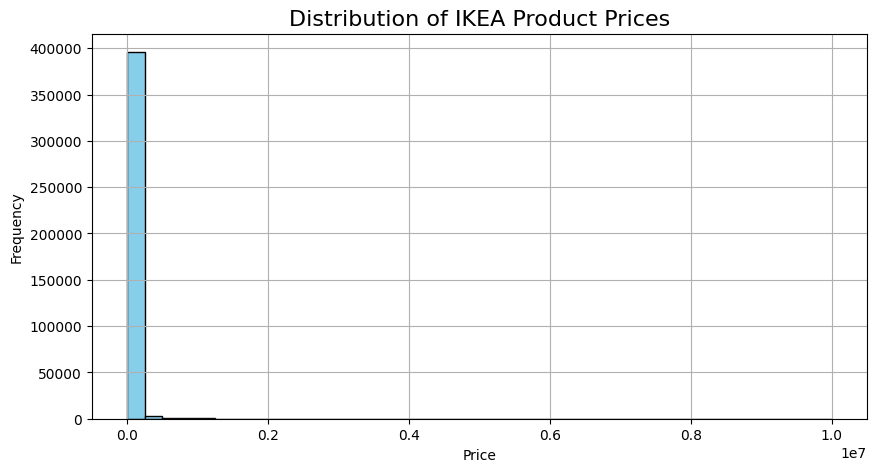

In [16]:
price_df = df.select("price").toPandas()

plt.figure(figsize=(10,5))

plt.hist(
    price_df["price"],
    bins=40,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of IKEA Product Prices", fontsize=16)
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

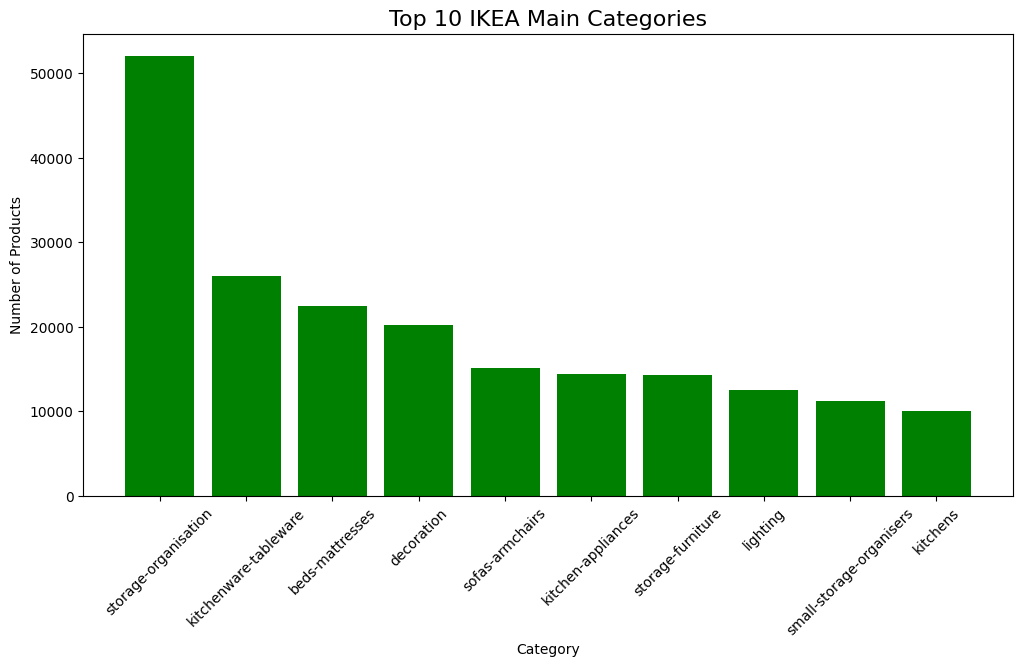

In [21]:
category_df = (
    df.groupBy("main_category")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(12,6))

colors = [
    "green"
]

plt.bar(
    category_df["main_category"],
    category_df["count"],
    color=colors
)

plt.xticks(rotation=45)

plt.title("Top 10 IKEA Main Categories", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

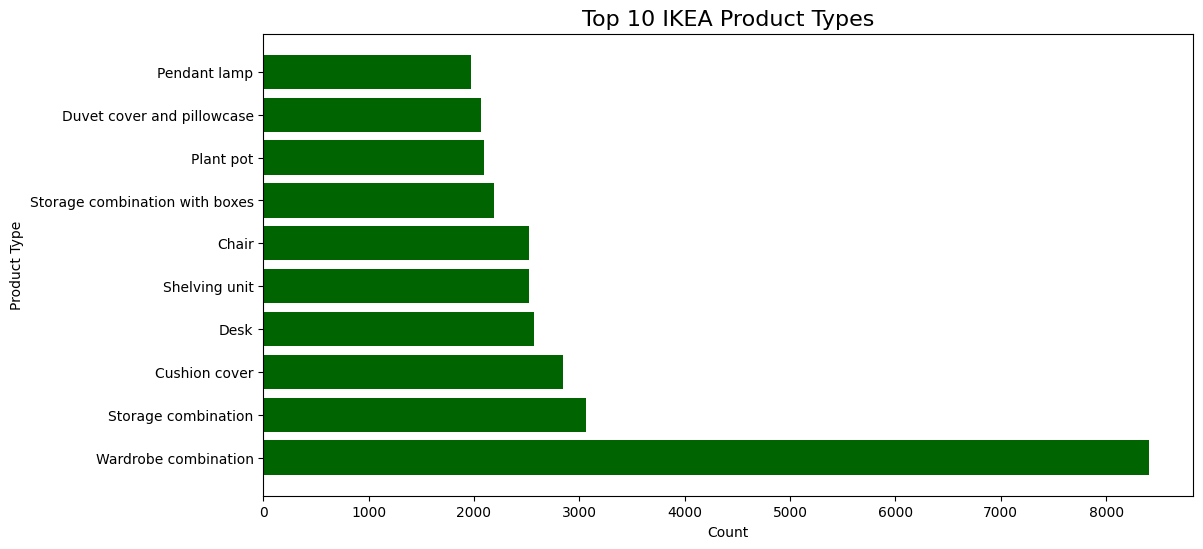

In [22]:
type_df = (
    df.groupBy("product_type")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(12,6))

colors = [
    "darkgreen"
]

plt.barh(
    type_df["product_type"],
    type_df["count"],
    color=colors
)

plt.title("Top 10 IKEA Product Types", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Product Type")

plt.show()

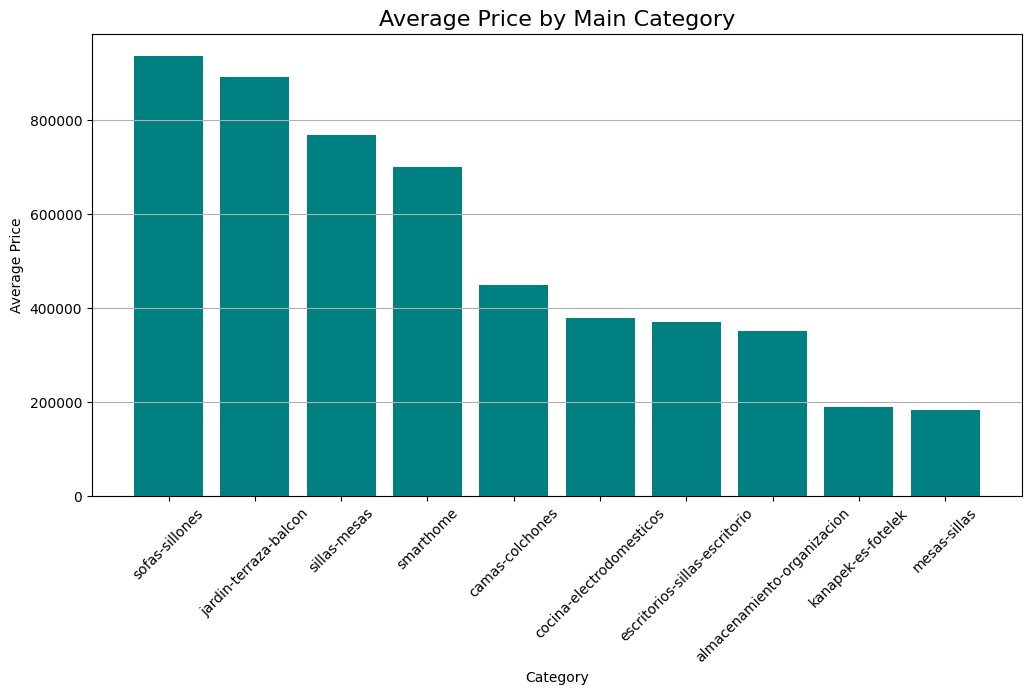

In [20]:
avg_price_df = (
    df.groupBy("main_category")
    .avg("price")
    .orderBy("avg(price)", ascending=False)
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(12,6))

colors = [
    "teal"
]

plt.bar(
    avg_price_df["main_category"],
    avg_price_df["avg(price)"],
    color=colors
)

plt.xticks(rotation=45)

plt.title("Average Price by Main Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Average Price")

plt.grid(axis="y")

plt.show()

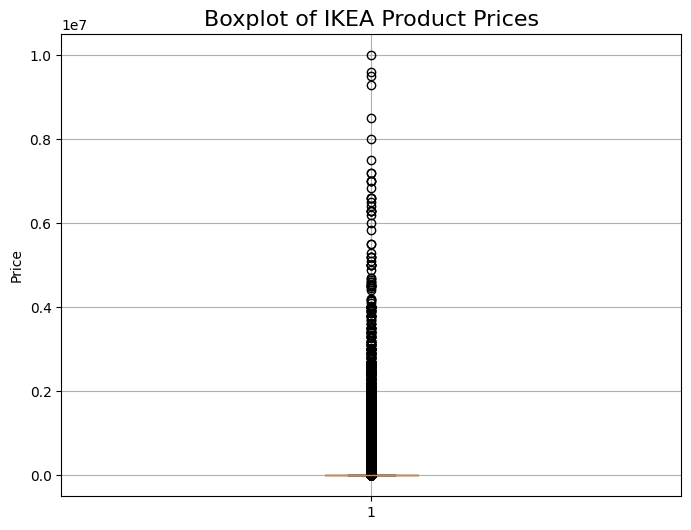

In [23]:
plt.figure(figsize=(8,6))

box = plt.boxplot(
    price_df["price"],
    patch_artist=True
)

# color styling
for patch in box['boxes']:
    patch.set_facecolor('yellow')

plt.title("Boxplot of IKEA Product Prices", fontsize=16)
plt.ylabel("Price")

plt.grid(True)

plt.show()

In [19]:
from IPython.display import display, HTML

display(
    HTML("""
    <style>
        .output_scroll {
            height: auto !important;
            max-height: none !important;
        }
    </style>
    """)
)

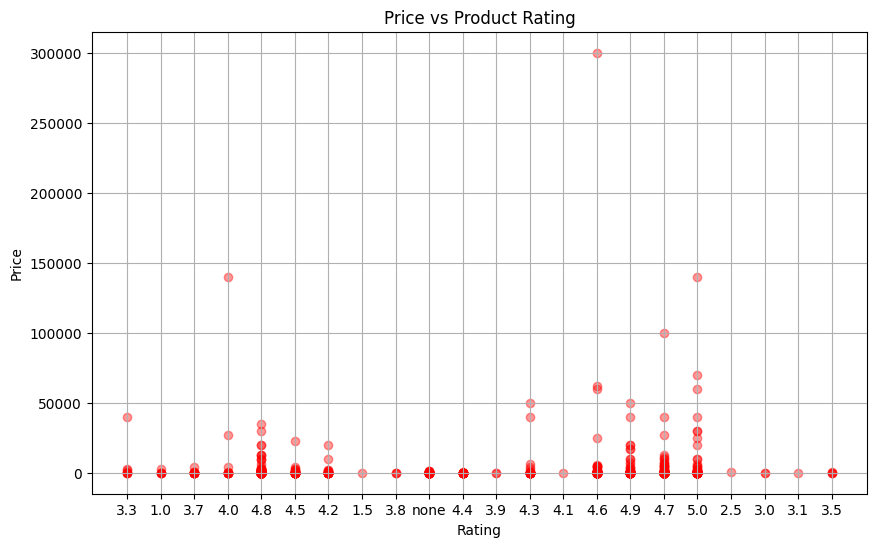

In [20]:
scatter_df = (
    df.select("price", "product_rating")
    .dropna()
    .limit(1000)
    .toPandas()
)

plt.figure(figsize=(10,6))

plt.scatter(
    scatter_df["product_rating"],
    scatter_df["price"],
    color="red",
    alpha=0.4
)

plt.title("Price vs Product Rating")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.grid(True)

plt.show()

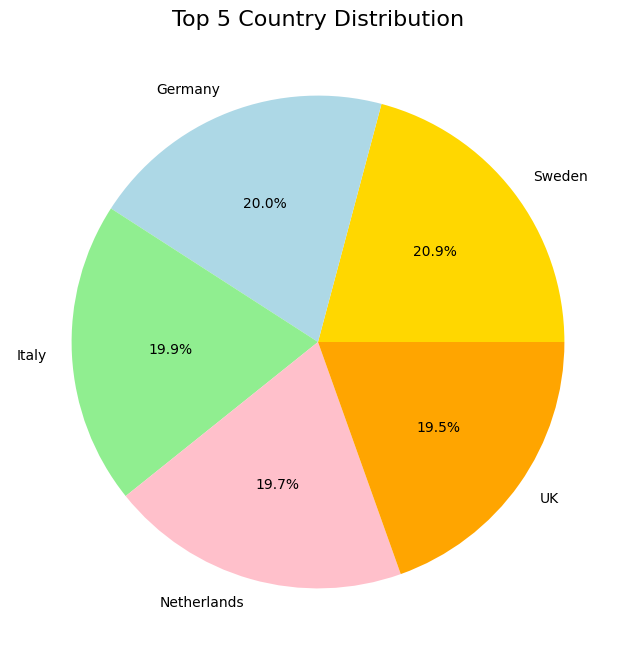

In [21]:
country_df = (
    df.groupBy("country")
    .count()
    .orderBy("count", ascending=False)
    .limit(5)
    .toPandas()
)

plt.figure(figsize=(8,8))

colors = [
    "gold",
    "lightblue",
    "lightgreen",
    "pink",
    "orange"
]

plt.pie(
    country_df["count"],
    labels=country_df["country"],
    autopct="%1.1f%%",
    colors=colors
)

plt.title("Top 5 Country Distribution", fontsize=16)

plt.show()

In [14]:
from pyspark.sql.functions import regexp_extract, when

df = df.withColumn(
    "size",
    when(
        regexp_extract(
            "product_measurements",
            r"(\d+\.?\d*)",
            1
        ) != "",
        regexp_extract(
            "product_measurements",
            r"(\d+\.?\d*)",
            1
        ).cast("float")
    ).otherwise(None)
)

In [15]:
from pyspark.sql.functions import length

df = df.withColumn(
    "desc_length",
    length("product_description").cast("float")
)

In [16]:
print(df.columns)

['unique_id', 'product_id', 'product_name', 'product_type', 'product_measurements', 'product_description', 'main_category', 'sub_category', 'product_rating', 'product_rating_count', 'badge', 'online_sellable', 'url', 'price', 'currency', 'discount', 'sale_tag', 'country', 'text_data', 'size', 'desc_length']


In [17]:
from pyspark.ml.feature import StringIndexer

category_indexer = StringIndexer(
    inputCol="main_category",
    outputCol="main_category_index",
    handleInvalid="keep"
)

df = category_indexer.fit(df).transform(df)

In [18]:
from pyspark.sql.functions import expr

df = df.withColumn(
    "product_rating",
    expr("try_cast(product_rating as float)")
)

In [19]:
df = df.dropna(
    subset=[
        "price",
        "product_rating",
        "size",
        "desc_length"
    ]
)

In [20]:
print(df.columns)

['unique_id', 'product_id', 'product_name', 'product_type', 'product_measurements', 'product_description', 'main_category', 'sub_category', 'product_rating', 'product_rating_count', 'badge', 'online_sellable', 'url', 'price', 'currency', 'discount', 'sale_tag', 'country', 'text_data', 'size', 'desc_length', 'main_category_index']


In [21]:
from pyspark.ml.feature import Tokenizer

tokenizer = Tokenizer(
    inputCol="product_description",
    outputCol="words"
)

df = tokenizer.transform(df)

In [22]:
df.select("product_description", "words").show(3, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------+
|product_description                                                                                                             |words                                                                                                                                            |
+--------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------+
|ORDNING Dish drainer, stainless steel, 50x27x36 cm                                                                              |[ordning, dish, drainer,, stainless, st

In [23]:
from pyspark.ml.feature import StopWordsRemover

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

df = remover.transform(df)

In [24]:
df.select("words", "filtered_words").show(3, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------+
|words                                                                                                                                            |filtered_words                                                                                                              |
+-------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------+
|[ordning, dish, drainer,, stainless, steel,, 50x27x36, cm]                                                                                       |[ordning, dish, drainer,, stainles

In [25]:
from pyspark.ml.feature import HashingTF

hashing_tf = HashingTF(
    inputCol="filtered_words",
    outputCol="text_features",
    numFeatures=8
)

df = hashing_tf.transform(df)

In [26]:
df.select("filtered_words", "text_features").show(3, truncate=False)

[Stage 18:>                                                         (0 + 1) / 1]

+----------------------------------------------------------------------------------------------------------------------------+-------------------------------------+
|filtered_words                                                                                                              |text_features                        |
+----------------------------------------------------------------------------------------------------------------------------+-------------------------------------+
|[ordning, dish, drainer,, stainless, steel,, 50x27x36, cm]                                                                  |(8,[1,4,5,7],[1.0,2.0,3.0,1.0])      |
|[ordning, stainless-steel, dish, drainer, two-tiered, racks., silver,, durable,, rectangular,, handles, perforated, bottom.]|(8,[0,1,2,4,5],[2.0,2.0,3.0,2.0,3.0])|
|[ordning, dish, drainer,, stainless, steel,, 50x27x36, cm]                                                                  |(8,[1,4,5,7],[1.0,2.0,3.0,1.0])      |
+---------

In [27]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "main_category_index",
        "product_rating",
        "size",
        "desc_length",
        "text_features"
    ],
    outputCol="features"
)

df = assembler.transform(df)

In [28]:
df.select("features").show(3, truncate=False)

[Stage 19:>                                                         (0 + 1) / 1]

+------------------------------------------------------------------+
|features                                                          |
+------------------------------------------------------------------+
|[1.0,3.299999952316284,50.0,50.0,0.0,1.0,0.0,0.0,2.0,3.0,0.0,1.0] |
|[1.0,3.299999952316284,50.0,128.0,2.0,2.0,3.0,0.0,2.0,3.0,0.0,0.0]|
|[1.0,1.0,50.0,50.0,0.0,1.0,0.0,0.0,2.0,3.0,0.0,1.0]               |
+------------------------------------------------------------------+
only showing top 3 rows


In [29]:
df = df.limit(12000)

In [30]:
print(df.count())

[Stage 22:>                                                         (0 + 1) / 1]

12000


In [31]:
train_df, test_df = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [32]:
print("Training Rows:", train_df.count())
print("Testing Rows:", test_df.count())

26/05/19 13:54:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Training Rows: 9663


Testing Rows: 2337


In [33]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="price",
    maxIter=10
)

lr_model = lr.fit(train_df)

26/05/19 13:56:43 WARN Instrumentation: [ec6657d4] regParam is zero, which might cause numerical instability and overfitting.
26/05/19 13:56:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/19 13:56:56 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

In [34]:
lr_predictions = lr_model.transform(test_df)

In [35]:
from pyspark.ml.evaluation import RegressionEvaluator

# RMSE
rmse_evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

# MAE
mae_evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="mae"
)

# R2
r2_evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_evaluator.evaluate(lr_predictions)
mae = mae_evaluator.evaluate(lr_predictions)
r2 = r2_evaluator.evaluate(lr_predictions)

print("Linear Regression RMSE:", rmse)
print("Linear Regression MAE:", mae)
print("Linear Regression R2:", r2)

Linear Regression RMSE: 67676.392185928
Linear Regression MAE: 14073.738566008513
Linear Regression R2: 0.005522427122252149


In [27]:
from pyspark.ml.feature import VectorAssembler

tree_assembler = VectorAssembler(
    inputCols=[
        "product_rating",
        "size",
        "desc_length"
    ],
    outputCol="tree_features"
)

df = tree_assembler.transform(df)

In [28]:
df = df.limit(8000)

In [29]:
tree_train, tree_test = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [30]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="tree_features",
    labelCol="price",
    maxDepth=5,
    maxBins=32
)

dt_model = dt.fit(tree_train)

26/05/19 17:31:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

In [31]:
dt_predictions = dt_model.transform(tree_test)

In [32]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_eval = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

mae_eval = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="mae"
)

r2_eval = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_eval.evaluate(dt_predictions)
mae = mae_eval.evaluate(dt_predictions)
r2 = r2_eval.evaluate(dt_predictions)

print("Decision Tree RMSE:", rmse)
print("Decision Tree MAE:", mae)
print("Decision Tree R2:", r2)

Decision Tree RMSE: 78731.60339173122
Decision Tree MAE: 15408.393630347633
Decision Tree R2: 0.06016712867411789


In [33]:
df_filtered = df.filter(df.price < 1000)

In [34]:
import pandas as pd

pandas_df = df_filtered.select(
    "product_name",
    "product_description",
    "price"
).limit(5000).toPandas()

pandas_df.head()

,product_name,product_description,price
0,ORDNING,"ORDNING Dish drainer, stainless steel, 50x27x3...",30.000000
1,ORDNING,An ORDNING stainless-steel dish drainer with t...,27.990000
2,ORDNING,"ORDNING Dish drainer, stainless steel, 50x27x3...",9.500000
3,ORDNING,An ORDNING stainless-steel dish drainer with t...,29.990000
4,ORDNING,"ORDNING Dish drainer, stainless steel, 19 5/8x...",34.990002


In [36]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [35]:
pandas_df["text"] = (
    pandas_df["product_name"].fillna("") + " " +
    pandas_df["product_description"].fillna("")
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    pandas_df["text"]
)

y = pandas_df["price"]

In [49]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

model.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [37]:
import pickle

pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump(pandas_df, open("products.pkl", "wb"))